# command line crispr-surf analysis

This was the command for making the required CRISPR-SURF table from fastqs:


docker run -v ${PWD}/:/DATA -w /DATA pinellolab/crisprsurf SURF_count -f sgRNA_library_file.csv -control_fastqs rep1_control.fastq rep2_control.fastq rep3_control.fastq -sample_fastqs rep1_sample.fastq rep2_sample.fastq rep3_sample.fastq -nuclease cas9 -pert crispri -sgRNA_length 20 -sgRNA_index 0 20 -count_method index



This was the command for running the CRISPR-SURF analysis:


docker run -v ${PWD}/:/DATA -w /DATA pinellolab/crisprsurf SURF_deconvolution -f sgRNAs_summary_table.csv -pert crispri -genome hg38

fastqs can be found here:
https://data.igvf.org/search/?type=MeasurementSet&query=TOX&lab.title=Charles+Gersbach%2C+Duke

# R part

In [3]:
source("/mnt/users/rachelsavage/paper_minimorf/code/figure_code/Figure_Code_Presets.r")
suppressPackageStartupMessages({
library(ggforce)
library(purrr)
library(ggtranscript)
library(DESeq2)
library(ggh4x)
library(ggbeeswarm)
library(ggrastr)})

# run DESeq

In [4]:
crispri.hits <- fread("/mnt/users/rachelsavage/minimorf_t_cell/data/data_from_christian/sgRNAs_summary_table_updated.csv")
crispri.hits$read.id <- paste0("read", 1:nrow(crispri.hits))
read.df <- crispri.hits[,c("read.id", "sgRNA_Type", "Chr", "Start", "Stop", "Strand", "Perturbation_Index")]

crispri.count.mx <- crispri.hits %>% 
dplyr::select(read.id, 
              Replicate1_Control_Count, Replicate2_Control_Count, Replicate3_Control_Count, 
              Replicate1_Sample_Count,Replicate2_Sample_Count,Replicate3_Sample_Count) %>%
column_to_rownames("read.id") %>% as.matrix()

sample.df <- data.frame(fullname = colnames(crispri.count.mx))%>%
mutate(replicate = stri_split_fixed(fullname, pattern = "_", simplify =TRUE)[,1],
       condition = stri_split_fixed(fullname, pattern = "_", simplify =TRUE)[,2]) %>%
mutate(condition = factor(condition, levels = c("Control", "Sample")))
rownames(sample.df) <- colnames(crispri.count.mx)

dds <- DESeqDataSetFromMatrix(
  countData = crispri.count.mx,
  colData   = sample.df,
  design    = ~ condition
)

dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [21]:
head(dds)

class: DESeqDataSet 
dim: 6 6 
metadata(1): version
assays(4): counts mu H cooks
rownames(6): read1 read2 ... read5 read6
rowData names(22): baseMean baseVar ... deviance maxCooks
colnames(6): Replicate1_Control_Count Replicate2_Control_Count ...
  Replicate2_Sample_Count Replicate3_Sample_Count
colData names(4): fullname replicate condition sizeFactor

In [ ]:
fwrite(dds)

# visualize the basics

In [24]:
res <- as.data.frame(results(dds, contrast = c("condition", "Control", "Sample"),independentFiltering = FALSE, cooksCutoff = Inf))
res$read.id <- rownames(res)
res <- res %>% left_join(read.df)


Joining with `by = join_by(read.id)`


In [26]:
fwrite(res, "/mnt/users/rachelsavage/paper_minimorf/data/IGVF_metadata/CRISPRi_deseq.out.csv")

Joining with `by = join_by(read.id)`



         read1460  read357 read3935 read6032 
    6729        1        1        1        1 

Warning message in geom_point(data = res.neg, aes(label = mylabel), color = "green4", :
“Ignoring unknown aesthetics: label”


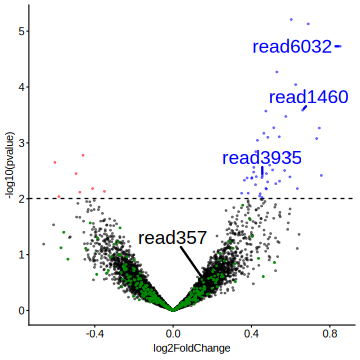

In [5]:
options(repr.plot.width = 3, repr.plot.height = 3)

res <- as.data.frame(results(dds, contrast = c("condition", "Control", "Sample"),independentFiltering = FALSE, cooksCutoff = Inf))
res$read.id <- rownames(res)
res <- res %>% left_join(read.df) %>%
mutate(mylabel = ifelse(read.id %in% c("read1","read6032", "read357","read1460", "read3935"), read.id, ""))

res.neg <- res %>% filter(sgRNA_Type == "negative_control")
res.expt <- res %>% filter(sgRNA_Type == "observation")

table(res.expt$mylabel)

crispri.volcano <- res.expt %>%
mutate(color = ifelse(pvalue<= 0.01& log2FoldChange>0, "blue", 
                      ifelse(pvalue<= 0.01 & log2FoldChange<0, "red", "black"))) %>%
ggplot(aes(x=log2FoldChange, y= -log10(pvalue), color = color, label = mylabel))+
geom_hline(yintercept = -log10(0.01), linetype = "dashed")+
geom_point(size = 0.1, alpha = 0.5)+
geom_point(data = res.neg, aes(label = mylabel), color = "green4", size = 0.1)+
theme_classic()+
scale_color_identity()+
rsav_theme+
geom_text_repel(max.overlaps = Inf, min.segment.length = 0)

crispri.volcano



Negative Control          TOX TSS        TOX other 
             305               55             6678 

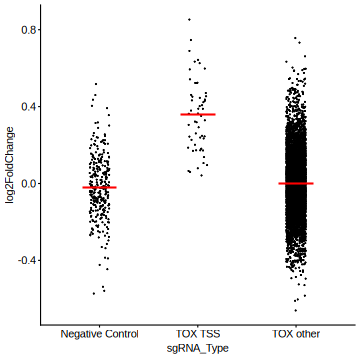

In [6]:
options(repr.plot.width = 3, repr.plot.height = 3)

jitterplt <- res %>%
mutate(Perturbation_Index= ifelse(is.na(Perturbation_Index), 0, Perturbation_Index))%>%
mutate(sgRNA_Type = ifelse(abs(59119147 - Perturbation_Index) < 500, "TOX TSS", 
                          ifelse(Perturbation_Index == 0, "Negative Control", "TOX other")))%>%
mutate(sgRNA_Type = factor(sgRNA_Type, levels = c("Negative Control", "TOX TSS", "TOX other")))%>% 
mutate(signed.p = -log10(padj) * sign(log2FoldChange))

table(jitterplt$sgRNA_Type)

jitterplt <- jitterplt%>%
ggplot(aes(x=sgRNA_Type, y= log2FoldChange))+
#geom_violin()+
rasterise(geom_jitter(height = 0, width = 0.1, size = 0.1), dpi=300)+
#geom_beeswarm()+
theme_classic()+
stat_summary(fun = mean, geom = "crossbar", width = 1/.pt, linewidth = 0.5/.pt, color = "red")+
rsav_theme

jitterplt

In [ ]:
ggsave("/mnt/users/rachelsavage/paper_minimorf/paper_figures/supplemental/suppfig3.crisprijitter.svg",
       plot = jitterplt, width = 1.5, height = 1.5, units = "in")

# roll mean for tox-locus wide plotting 

In [7]:
setDT(res.expt)
res2 <- res.expt[
  , .(log2FoldChange = mean(log2FoldChange, na.rm = TRUE)),
  by = Perturbation_Index
]
all_pos <- data.table(
  Perturbation_Index = seq(
    min(res2$Perturbation_Index, na.rm = TRUE),
    max(res2$Perturbation_Index, na.rm = TRUE)
  )
)

dt <- res2[all_pos, on = "Perturbation_Index"]
dt[, smooth := frollmean(log2FoldChange, n = 1000, align = "center", na.rm = TRUE)]

In [8]:
## saving this bedgraph, uploading online so that I can use IGV to visualize it. 

bedgraph <- dt %>% filter(!is.na(smooth)) %>% 
mutate(chr = "chr8") %>% 
mutate(end = Perturbation_Index+1)%>%
dplyr::select(chr, Perturbation_Index, end, smooth) %>%
arrange(chr, Perturbation_Index)

head(bedgraph)

options(scipen = 999)
fwrite(bedgraph, "/mnt/users/rachelsavage/paper_minimorf/data/tox_locus/crispri.bedgraph", sep = "\t", col.names = FALSE)

# bedGraphToBigWig crispri.bedgraph /mnt/users/rachelsavage/paper_minimorf/data/reference_data/hg38.chrom.sizes crispri.bw
#  gsutil cp crispri.bw xxxx location for IGV ploting 

chr,Perturbation_Index,end,smooth
<chr>,<int>,<dbl>,<dbl>
chr8,58706094,58706095,-0.07084411
chr8,58706095,58706096,-0.09447945
chr8,58706096,58706097,-0.09447945
chr8,58706097,58706098,-0.09447945
chr8,58706098,58706099,-0.09447945
chr8,58706099,58706100,-0.09447945


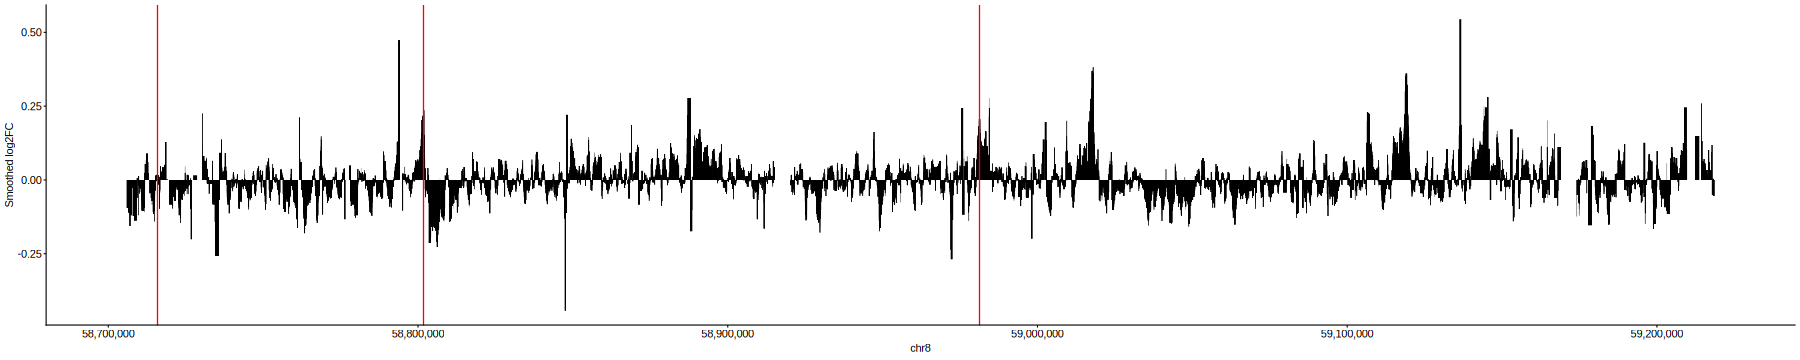

In [9]:
options(repr.plot.width = 15, repr.plot.height = 3)
smoothed.logfcplot <- dt %>%
filter(!is.na(smooth))%>%
ggplot()+
#geom_vline(xintercept = 59119147, color = "red", alpha=0.1)+
rasterise(
    geom_linerange(aes(x=Perturbation_Index, ymin = 0, ymax=smooth), linewidth = 0.1),
    dpi = 300)+
scale_x_continuous(limits = c(min(res.expt$Perturbation_Index), max(res.expt$Perturbation_Index)),    labels = label_comma())+
rsav_theme+
xlab("chr8")+
ylab("Smoothed log2FC")+
geom_vline(xintercept = 58715888, color = "red")+
geom_vline(xintercept = 58801660, color = "red")+
geom_vline(xintercept = 58981205, color = "red")


smoothed.logfcplot

In [ ]:
ggsave("/mnt/users/rachelsavage/paper_minimorf/paper_figures/supplemental/suppfig3.crispri.toxlocus.svg",
       plot = vertical.plot, width = 5.5, height = 1.5, units = "in")

# De novo motif overlay

In [10]:
dnm <- readRDS("/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/denovo.motif.locations.gr.rds")

In [11]:
full.length.tox <- GRanges(seqnames = "chr8",
                           ranges = IRanges(start = min(res.expt$Perturbation_Index),
                                            end = max(res.expt$Perturbation_Index)))

asdf <- findOverlaps(query = dnm, subject = full.length.tox) 
dnm.in.tox <- dnm[queryHits(asdf)]

In [12]:
# at each DNM, get the deseq results.  plot box plot. 
res.in <- res %>% 
mutate(Chr = "chr8")%>%
mutate(Start = ifelse(sgRNA_Type == "observation", Start, 1),
       Stop = ifelse(sgRNA_Type == "observation", Start, 10))
crispri.gr <- GRanges(seqnames = "chr8",
                      ranges = IRanges(start = res.in$Start,
                                       end = res.in$Stop))
crispri.gr$log2FC <- res.in$log2FoldChange
crispri.gr$pvalue <- res.in$pvalue
crispri.gr$stat <- res.in$stat
crispri.gr$perturb.index <- res.in$Perturbation_Index
crispri.gr$read.id <- res.in$read.id
dnm.in.tox.in <- dnm.in.tox

asdf <- GRanges(seqnames = "chr8", 
                ranges = IRanges(start = c(1, 59119147),end = c(10, 59119147)))
asdf$motif_finalname <- c("neg_control","TSS")

dnm.in.tox.in <- c(dnm.in.tox.in, asdf)
dnm.in.tox.in$motif.location <- start(dnm.in.tox.in)
dnm.in.tox.in <- resize(dnm.in.tox.in, width = 500, fix = "center")

dnm.overlaps <- findOverlaps(query = crispri.gr, subject = dnm.in.tox.in)
dnm.overlaps.df <- data.frame(motif = dnm.in.tox.in$motif_finalname[subjectHits(dnm.overlaps)],
                              motif.start = dnm.in.tox.in$motif.location[subjectHits(dnm.overlaps)],
                             log2fc = crispri.gr$log2FC[queryHits(dnm.overlaps)],
                             pvalue = crispri.gr$pvalue[queryHits(dnm.overlaps)],
                             stat = crispri.gr$stat[queryHits(dnm.overlaps)],
                             grna.pos = crispri.gr$perturb.index[queryHits(dnm.overlaps)],
                             grna.read.id = crispri.gr$read.id[queryHits(dnm.overlaps)])
tail(dnm.overlaps.df)

,motif,motif.start,log2fc,pvalue,stat,grna.pos,grna.read.id
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
26566,NFKB_9_Count,59215377,-0.10811037,0.51872974,-0.64530472,59215642,read7006
26567,RUNX_1_Count,59215454,-0.10811037,0.51872974,-0.64530472,59215642,read7006
26568,RUNX_1_Count,59215454,0.01400452,0.94821635,0.06494681,59215657,read7007
26569,RUNX_1_Count,59215454,0.29962094,0.03689643,2.08690829,59215689,read7008
26570,RUNX_1_Count,59215454,0.10259361,0.52370051,0.63765158,59215697,read7009
26571,RUNX_1_Count,59215454,0.18096847,0.36209022,0.91138942,59215712,read7010


In [13]:
asdf <- dnm.overlaps.df %>% filter(motif == "TSS")
mean(asdf$log2fc)

asdf <- dnm.overlaps.df %>% filter(motif == "NRF_19_Footprint")
mean(asdf$log2fc)

asdf <- dnm.overlaps.df %>% filter(motif == "RUNX+KLF_114_Footprint")
mean(asdf$log2fc)

0.244168276261173/0.367742629412153

[1] 0.3677426

[1] 0.2441683

[1] 0.1730431

[1] 0.6639651

In [14]:
tss.grnas <- dnm.overlaps.df %>% filter(motif == "TSS")

head(tss.grnas)

,motif,motif.start,log2fc,pvalue,stat,grna.pos,grna.read.id
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,TSS,59119147,0.22692320,0.28973855,1.058695,59118930,read6024
2,TSS,59119147,0.04184439,0.82069824,0.226647,59118934,read6025
3,TSS,59119147,0.42301065,0.01598730,2.409205,59118935,read6026
4,TSS,59119147,0.17156444,0.24279348,1.168033,59119118,read6027
5,TSS,59119147,0.59361779,0.01867019,2.352052,59119198,read6028
6,TSS,59119147,0.30501829,0.04169042,2.036597,59119199,read6029


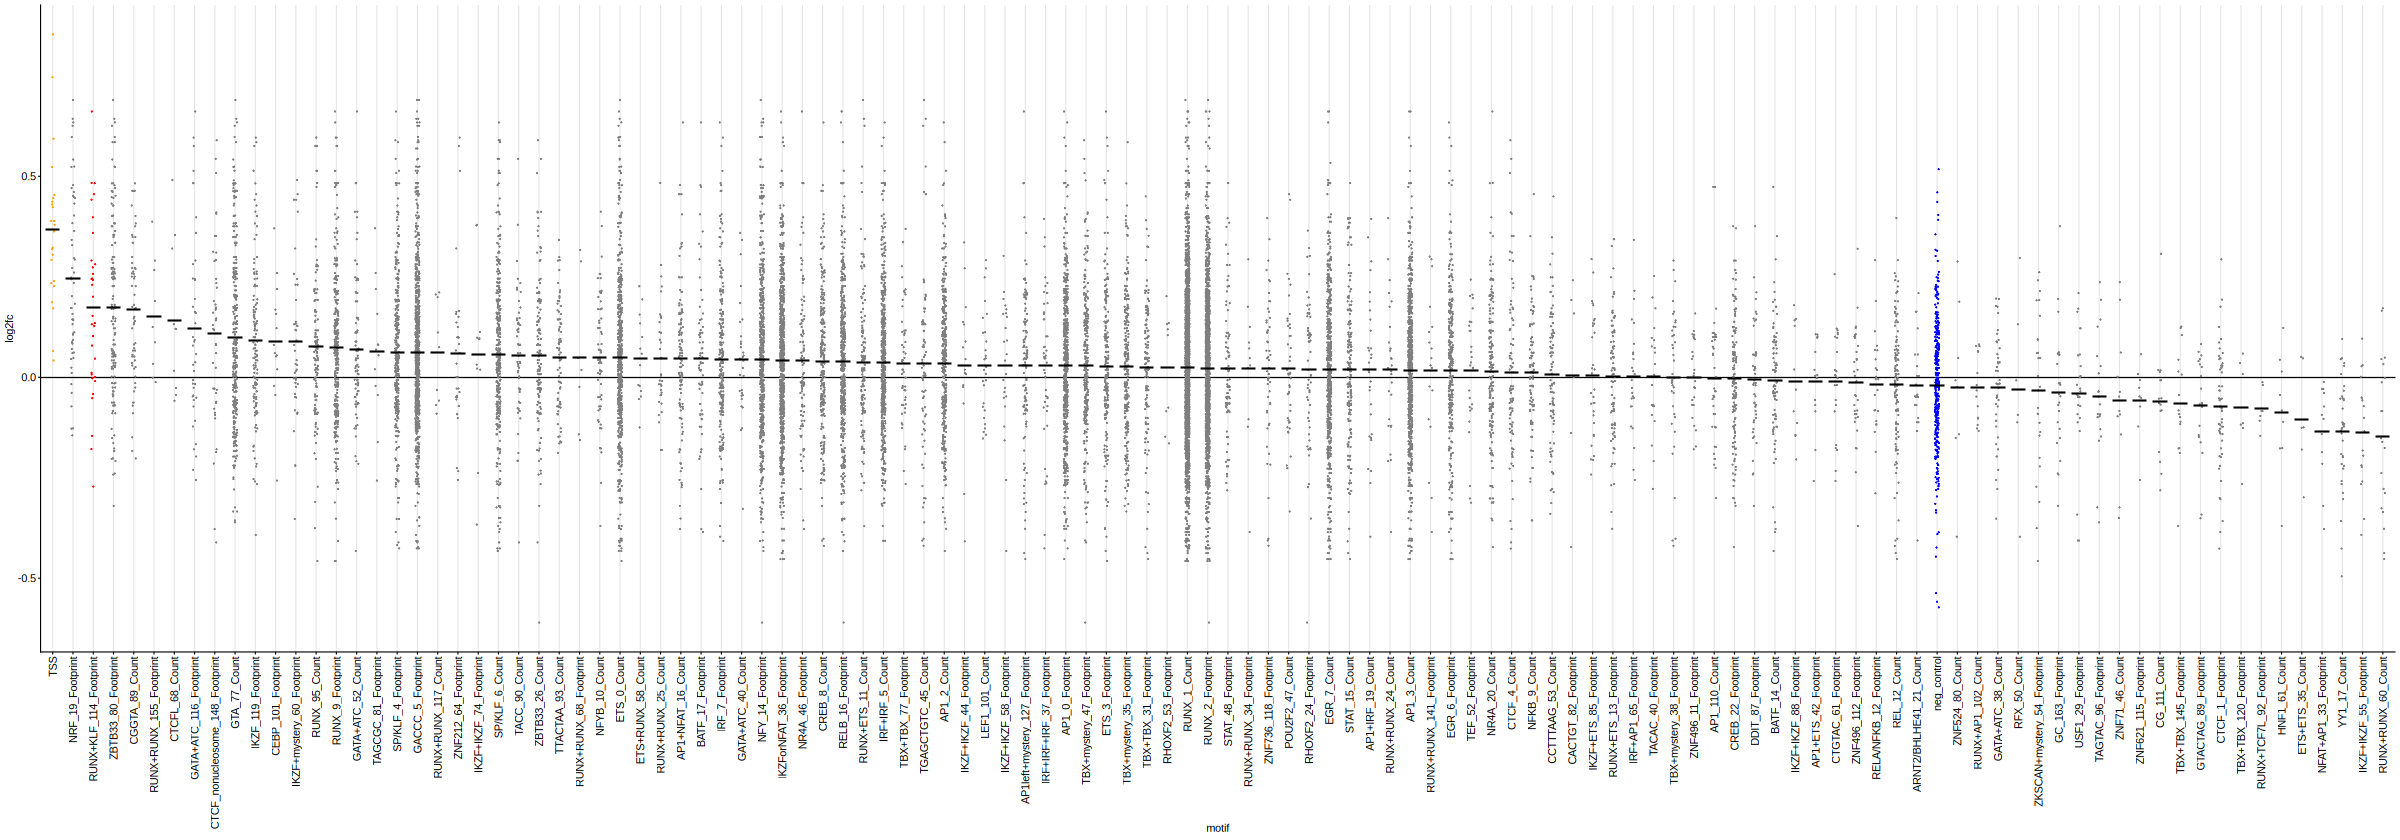

In [16]:
## filtering out a few motifs: poly are these polyA stuff, CXXC1 are just CG's. 
# and then i am requiring a motif to have more than 5 guides covering it to count. 

options(repr.plot.width = 20, repr.plot.height = 7)

pointplot.in <- dnm.overlaps.df %>%
filter(!grepl("poly", motif))%>%
filter(!grepl("CXXC1", motif))%>%
filter(motif == "TSS" | !(grna.pos %in% tss.grnas$grna.pos)) %>% 
#filter(grepl("RUNX|TSS|neg_control|EGR|KLF", motif))%>%
#filter(motif %in% c("RUNX+KLF_114_Footprint", "RUNX_1_Count", "EGR_7_Count", "SP/KLF_6_Count","TSS","neg_control"))%>%
group_by(motif)%>%
mutate(mean = mean(log2fc),
          sd = sd(log2fc),
          num = n())%>%
mutate(sem = sd / sqrt(num))%>%
ungroup()%>%
filter(num>5)%>%
arrange(-mean)%>%
mutate(rank = row_number())%>%
mutate(motif = factor(motif, levels = unique(motif)))%>%
mutate(color = ifelse(motif == "TSS", "orange",
                      ifelse(motif == "neg_control", "blue", 
                             ifelse(motif == "RUNX+KLF_114_Footprint", "red", "grey50"))))
pointplot <- pointplot.in %>% 
ggplot(aes(x=motif, y= log2fc, color = color))+
geom_hline(yintercept = 0)+
rasterise(
    geom_jitter(size = 0.1, width = 0.1, height = 0),
    dpi = 300)+
stat_summary(fun = mean, geom = "crossbar", width = 2/.pt, linewidth = 0.5/.pt, color = "black")+
theme_classic()+
rsav_theme+
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
scale_color_identity()+
theme(panel.grid.major.x = element_line(color = "grey90"))

pointplot


In [ ]:
ggsave("/mnt/users/rachelsavage/paper_minimorf/paper_figures/supplemental/suppfig3.crispri.allmotifs.svg",
       plot = pointplot, width = 7.5, height = 2, units = "in")


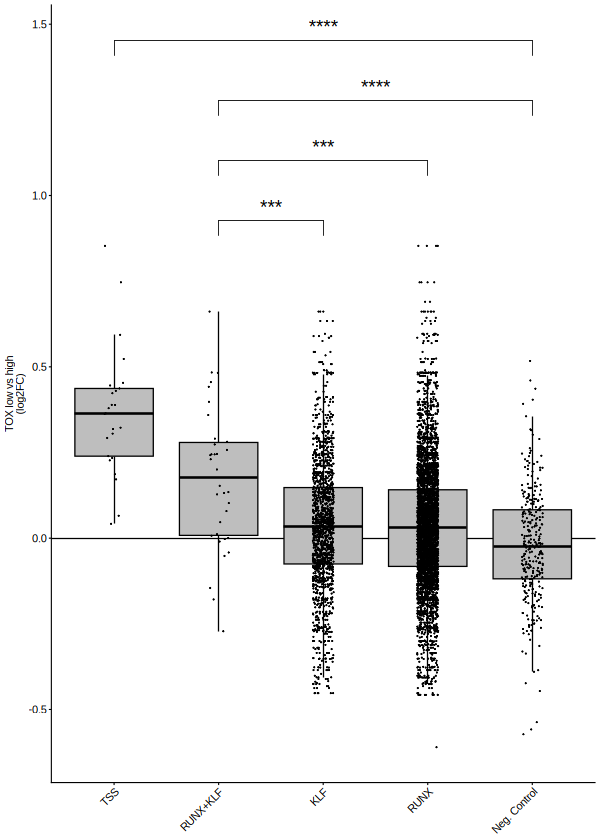

In [17]:
options(repr.plot.width = 5, repr.plot.height = 7)

my_comparisons <- list(#c("neg_control", "RUNX_2_Footprint"),
                       #c("neg_control", "SP/KLF_4_Footprint"), 
                                                 c("RUNX+KLF", "KLF"), 
                                                     c("RUNX+KLF", "RUNX"), 
                                             c("Neg. Control", "RUNX+KLF"),
                                                 c("Neg. Control", "TSS"))

pointplot.in <- dnm.overlaps.df %>%
mutate(motif = case_when(motif %in% c("EGR_6_Footprint", "EGR_7_Count",
                                                 "SP/KLF_4_Footprint", "SP/KLF_6_Count") ~ "KLF",
                          motif %in% c("RUNX_1_Count", "RUNX_2_Footprint", "RUNX_9_Footprint") ~ "RUNX",
                          motif %in% c("RUNX+KLF_114_Footprint") ~ "RUNX+KLF",
                         motif == "neg_control" ~ "Neg. Control",
                         motif == "TSS" ~ "TSS",
                          .default = "other")) %>%
filter(motif != "other") %>% # | grepl("TSS", motif))%>%
group_by(motif)%>%
mutate(mean = mean(log2fc),
          sd = sd(log2fc),
          num = n())%>%
mutate(sem = sd / sqrt(num))%>%
ungroup()%>%
filter(num>5)%>%
arrange(-mean)%>%
mutate(rank = row_number())%>%
mutate(motif = factor(motif, levels = unique(motif)))%>%
mutate(color = ifelse(motif == "TSS", "orange",
                      ifelse(motif == "Neg. Control", "blue", 
                             ifelse(motif == "RUNX+KLF", "red", "grey50"))))

pointplot <- pointplot.in %>%
#mutate(color = ifelse(grna.read.id == "read3935", "red", "black")) %>%
ggplot(aes(x=motif, y= log2fc, fill = color))+
geom_hline(yintercept = 0)+
geom_boxplot(outliers = FALSE, color = "black", fill = "grey")+
rasterise(
    geom_jitter(size = 0.1, width = 0.1, height = 0),
    dpi = 300)+
theme_classic()+
rsav_theme+
#theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
#scale_color_identity()+
scale_fill_identity()+
stat_compare_means(label = "p.signif", method = "t.test", comparisons = my_comparisons, bracket.size = 0.5/.pt)+
xlab(NULL)+
ylab("TOX low vs high\n(log2FC)")+
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))

pointplot

In [ ]:
ggsave("/mnt/users/rachelsavage/paper_minimorf/paper_figures/fig3/crispri.boxplot.svg",
       pointplot,
       height = 1.7,
       width = 1.7)

# guide individual examples

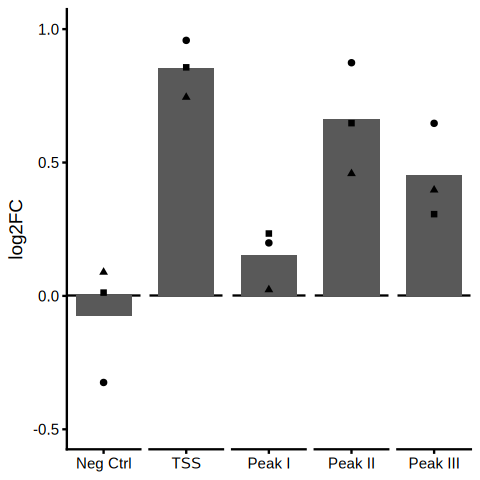

In [18]:
options(repr.plot.width = 4, repr.plot.height = 4)

df <- crispri.hits %>% filter(read.id %in% c("read1","read6032", "read1460", "read3935", "read357")) %>%
dplyr::select(read.id,Log2FC_Replicate1,Log2FC_Replicate2,Log2FC_Replicate3)%>%
pivot_longer(!read.id) %>%
mutate(read.id.peak = dplyr::recode(
    read.id,
    "read1" = "Neg Ctrl",
    "read6032" = "TSS",
    "read357" = "Peak I",
    "read1460" = "Peak II",
    "read3935" = "Peak III",
  ))  %>%
mutate(value = -value)%>%
mutate(read.id.peak = factor(read.id.peak, levels = c("Neg Ctrl", "TSS", "Peak I", "Peak II", "Peak III")))

df.summary <- df %>% group_by(read.id.peak)%>%
summarize(meanfc = mean(value))

ggplot(df, aes(x=read.id.peak, y= value))+
geom_hline(yintercept = 0)+
geom_bar(data = df.summary, aes(x=read.id.peak, y= meanfc),  stat = "identity")+
geom_point(aes(shape = name))+
theme_classic()+
ylab("log2FC")+
xlab(NULL)+
facet_wrap2(~read.id.peak, scales = "free_x", 
            strip = strip_vanilla(),
nrow = 1)+
scale_y_continuous(limits = c(-0.5,1))+
theme(legend.position = "none")+
theme(strip.text = element_blank())
